# DuckDB
total execution time: 2.61s

In [4]:
import duckdb

# Paths
db_path = 'transactions.duckdb'
csv_path = 'PS_20174392719_1491204439457_log.csv'

# Connect to DuckDB
conn = duckdb.connect(db_path)

# Load CSV directly into a table
conn.execute(f"""
CREATE OR REPLACE TABLE trxns AS 
SELECT * FROM read_csv_auto('{csv_path}', HEADER=True);
""")

In [66]:
import polars as pl

pl_trxns = pl.from_arrow(
    duckdb.connect("transactions.duckdb")
           .execute("SELECT * FROM trxns")
           .arrow()
).lazy()

In [42]:
%%time

# one-to-many
aggr_trxn = (
    pl_trxns
    .filter(pl.col("amount") >= 10_000)
    .group_by(["type", "nameOrig"])
    .agg([
        pl.col("nameDest").n_unique().alias("unique_counterparties"),
        pl.col("amount").sum().alias("aggr_trxn_amt"),
        pl.col("amount").count().alias("aggr_trxn_ct")
         ])
    .filter(pl.col("unique_counterparties") > 1)
    .sort("nameOrig", descending = False)
    .with_columns([
        pl.lit("one-to-many").alias("relationship_type"),
        pl.lit("sender").alias("party")
    ])
    .rename({"nameOrig": "party_id"})
    .collect(engine = "gpu")
)

# many-to-one
aggr_trxn_opp = (
    pl_trxns
    .filter(pl.col("amount") >= 10_000)
    .group_by(["type", "nameDest"])
    .agg([
        pl.col("nameOrig").n_unique().alias("unique_counterparties"),
        pl.col("amount").sum().alias("aggr_trxn_amt"),
        pl.col("amount").count().alias("aggr_trxn_ct"),
         ])
    .filter(pl.col("unique_counterparties") > 1)
    .sort("nameDest", descending = False)
    .with_columns([
        pl.lit("many-to-one").alias("relationship_type"),
        pl.lit("recipient").alias("party")
    ])
    .rename({"nameDest": "party_id"})
    .collect(engine = "gpu")
)

# concatenate the transaction aggragations
trxn_concat = pl.concat([aggr_trxn, aggr_trxn_opp], how = "vertical")


CPU times: user 1.04 s, sys: 209 ms, total: 1.25 s
Wall time: 1.06 s


In [67]:
# Store the Polars DataFrame as a new table

conn.register("aggr_trxn", aggr_trxn)
conn.execute("CREATE OR REPLACE TABLE aggr_trxn AS SELECT * FROM aggr_trxn")

conn.register("aggr_trxn_opp", aggr_trxn_opp)
conn.execute("CREATE OR REPLACE TABLE aggr_trxn_opp AS SELECT * FROM aggr_trxn_opp")

conn.register("trxn_concat", trxn_concat)
conn.execute("CREATE OR REPLACE TABLE trxn_concat AS SELECT * FROM trxn_concat")

In [68]:
%%time

rules = [
    {"relationship_type": "one-to-many", "type": "CASH_IN", "aggr_trxn_amt": 600_000, "aggr_trxn_ct": 2, "unique_counterparties": 2},
    {"relationship_type": "one-to-many", "type": "CASH_OUT", "aggr_trxn_amt": 600_000, "aggr_trxn_ct": 3, "unique_counterparties": 3},
    {"relationship_type": "one-to-many", "type": "TRANSFER", "aggr_trxn_amt": 6_000_000, "aggr_trxn_ct": 2, "unique_counterparties": 2},
    {"relationship_type": "one-to-many", "type": "PAYMENT", "aggr_trxn_amt": 60_000, "aggr_trxn_ct": 2, "unique_counterparties": 2},
    {"relationship_type": "many-to-one", "type": "CASH_IN", "aggr_trxn_amt": 5_000_000, "aggr_trxn_ct": 5, "unique_counterparties": 5},
    {"relationship_type": "many-to-one", "type": "CASH_OUT", "aggr_trxn_amt": 10_000_000, "aggr_trxn_ct": 5, "unique_counterparties": 5},
    {"relationship_type": "many-to-one", "type": "TRANSFER", "aggr_trxn_amt": 80_000_000, "aggr_trxn_ct": 4, "unique_counterparties": 4},
    {"relationship_type": "many-to-one", "type": "PAYMENT", "aggr_trxn_amt": 60_000, "aggr_trxn_ct": 2, "unique_counterparties": 2},
]

expr = None
for rule in rules:
    cond = (
        (pl.col("relationship_type") == rule["relationship_type"]) &
        (pl.col("type") == rule["type"]) &
        (pl.col("aggr_trxn_amt") >= rule["aggr_trxn_amt"]) &
        (pl.col("aggr_trxn_ct") >= rule["aggr_trxn_ct"]) &
        (pl.col("unique_counterparties") >= rule["unique_counterparties"])
    )
    expr = cond if expr is None else (expr | cond)

trxn_concat_intermediate = (
    trxn_concat.lazy()
    .with_columns([
        pl.when(expr).then(pl.lit("Y")).otherwise(pl.lit("N")).alias("is_sar")
    ])
    .collect(engine="gpu")
)

trxn_final = (
    trxn_concat_intermediate.lazy()
    .filter(pl.col("is_sar") == "Y")
    .collect(engine="gpu")
)


CPU times: user 120 ms, sys: 56.9 ms, total: 177 ms
Wall time: 95.5 ms


In [69]:
conn.register("trxn_concat_intermediate", trxn_concat_intermediate)
conn.execute("CREATE OR REPLACE TABLE trxn_concat_intermediate AS SELECT * FROM trxn_concat_intermediate")

conn.register("trxn_final", trxn_final)
conn.execute("CREATE OR REPLACE TABLE trxn_final AS SELECT * FROM trxn_final")

In [73]:
trxn_final

type,party_id,unique_counterparties,aggr_trxn_amt,aggr_trxn_ct,relationship_type,party,is_sar
str,str,i32,f64,u32,str,str,str
"""PAYMENT""","""C1004685418""",2,86082.62,2,"""one-to-many""","""sender""","""Y"""
"""PAYMENT""","""C1008178625""",2,71516.38,2,"""one-to-many""","""sender""","""Y"""
"""PAYMENT""","""C1023171688""",2,68463.3,2,"""one-to-many""","""sender""","""Y"""
"""PAYMENT""","""C1032840178""",2,105353.44,2,"""one-to-many""","""sender""","""Y"""
"""PAYMENT""","""C1097224105""",2,64675.74,2,"""one-to-many""","""sender""","""Y"""
…,…,…,…,…,…,…,…
"""PAYMENT""","""M757872464""",2,77573.66,2,"""many-to-one""","""recipient""","""Y"""
"""PAYMENT""","""M90144404""",2,72003.58,2,"""many-to-one""","""recipient""","""Y"""
"""PAYMENT""","""M961835845""",2,67476.93,2,"""many-to-one""","""recipient""","""Y"""


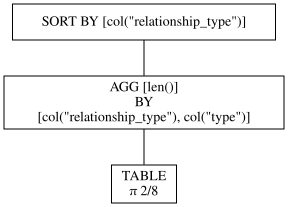

In [79]:
(
    trxn_final.lazy()
    .group_by(["relationship_type", "type"])
    .len()
    .sort("relationship_type")
    # .collect()
).show_graph(engine = "gpu")

In [80]:
(
    trxn_final.lazy()
    .group_by(["relationship_type", "type"])
    .len()
    .sort("relationship_type")
    .collect(engine = "gpu")
)

relationship_type,type,len
str,str,u32
"""many-to-one""","""CASH_IN""",74
"""many-to-one""","""PAYMENT""",35
"""many-to-one""","""TRANSFER""",162
"""many-to-one""","""CASH_OUT""",91
"""one-to-many""","""CASH_IN""",37
"""one-to-many""","""PAYMENT""",49
"""one-to-many""","""TRANSFER""",4
"""one-to-many""","""CASH_OUT""",1


In [81]:
# Close connection
conn.close()

In [8]:
# %%time

# # Connect to DuckDB
# conn = duckdb.connect(db_path)

# # Run the transformation queries
# conn.execute("""
# CREATE OR REPLACE TABLE aggr_trxn AS
# SELECT 
#     type, 
#     nameOrig AS party_id, 
#     COUNT(DISTINCT nameDest) AS unique_counterparties, 
#     SUM(amount) AS aggr_trxn_amt, 
#     COUNT(amount) AS aggr_trxn_ct,
#     'one-to-many' AS relationship_type, 
#     'sender' AS party
# FROM trxns
# WHERE amount >= 10000
# GROUP BY type, nameOrig
# HAVING COUNT(DISTINCT nameDest) > 1;

# CREATE OR REPLACE TABLE aggr_trxn_opp AS
# SELECT 
#     type, 
#     nameDest AS party_id, 
#     COUNT(DISTINCT nameOrig) AS unique_counterparties, 
#     SUM(amount) AS aggr_trxn_amt, 
#     COUNT(amount) AS aggr_trxn_ct,
#     'many-to-one' AS relationship_type, 
#     'recipient' AS party
# FROM trxns
# WHERE amount >= 10000
# GROUP BY type, nameDest
# HAVING COUNT(DISTINCT nameOrig) > 1;

# CREATE OR REPLACE TABLE trxn_concat AS
# SELECT * FROM aggr_trxn
# UNION ALL
# SELECT * FROM aggr_trxn_opp;

# CREATE OR REPLACE TABLE trxn_concat_inntermediate AS
# SELECT *,
#     CASE 
#         WHEN relationship_type = 'one-to-many' AND type = 'CASH_IN'    AND aggr_trxn_amt >= 600000   AND aggr_trxn_ct >= 2 AND unique_counterparties >= 2 THEN 'Y'
#         WHEN relationship_type = 'one-to-many' AND type = 'CASH_OUT'   AND aggr_trxn_amt >= 600000   AND aggr_trxn_ct >= 3 AND unique_counterparties >= 3 THEN 'Y'
#         WHEN relationship_type = 'one-to-many' AND type = 'TRANSFER'   AND aggr_trxn_amt >= 6000000  AND aggr_trxn_ct >= 2 AND unique_counterparties >= 2 THEN 'Y'
#         WHEN relationship_type = 'one-to-many' AND type = 'PAYMENT'    AND aggr_trxn_amt >= 60000    AND aggr_trxn_ct >= 2 AND unique_counterparties >= 2 THEN 'Y'
#         WHEN relationship_type = 'many-to-one' AND type = 'CASH_IN'    AND aggr_trxn_amt >= 5000000  AND aggr_trxn_ct >= 5 AND unique_counterparties >= 5 THEN 'Y'
#         WHEN relationship_type = 'many-to-one' AND type = 'CASH_OUT'   AND aggr_trxn_amt >= 10000000 AND aggr_trxn_ct >= 5 AND unique_counterparties >= 5 THEN 'Y'
#         WHEN relationship_type = 'many-to-one' AND type = 'TRANSFER'   AND aggr_trxn_amt >= 80000000 AND aggr_trxn_ct >= 4 AND unique_counterparties >= 4 THEN 'Y'
#         WHEN relationship_type = 'many-to-one' AND type = 'PAYMENT'    AND aggr_trxn_amt >= 60000    AND aggr_trxn_ct >= 2 AND unique_counterparties >= 2 THEN 'Y'
#         ELSE 'N'
#     END AS is_sar
# FROM trxn_concat;

# CREATE OR REPLACE TABLE trxn_final AS
# SELECT *
# FROM trxn_concat_inntermediate
# WHERE is_sar = 'Y';
# """)

# # Fetch summary counts
# rows = conn.execute("""
# SELECT relationship_type, type, COUNT(*) 
# FROM trxn_final 
# GROUP BY relationship_type, type 
# ORDER BY relationship_type, type;
# """).fetchall()

# # Display results
# for row in rows:
#     print(row)

# # Close connection
# conn.close()

('many-to-one', 'CASH_IN', 74)
('many-to-one', 'CASH_OUT', 91)
('many-to-one', 'PAYMENT', 35)
('many-to-one', 'TRANSFER', 162)
('one-to-many', 'CASH_IN', 37)
('one-to-many', 'CASH_OUT', 1)
('one-to-many', 'PAYMENT', 49)
('one-to-many', 'TRANSFER', 4)
CPU times: user 12.1 s, sys: 1.5 s, total: 13.6 s
Wall time: 1.24 s


# Put All Code Together and Count the Time

In [82]:
%%time 

pl_trxns = pl.from_arrow(
    duckdb.connect("transactions.duckdb")
           .execute("SELECT * FROM trxns")
           .arrow()
).lazy()

# one-to-many
aggr_trxn = (
    pl_trxns
    .filter(pl.col("amount") >= 10_000)
    .group_by(["type", "nameOrig"])
    .agg([
        pl.col("nameDest").n_unique().alias("unique_counterparties"),
        pl.col("amount").sum().alias("aggr_trxn_amt"),
        pl.col("amount").count().alias("aggr_trxn_ct")
         ])
    .filter(pl.col("unique_counterparties") > 1)
    .sort("nameOrig", descending = False)
    .with_columns([
        pl.lit("one-to-many").alias("relationship_type"),
        pl.lit("sender").alias("party")
    ])
    .rename({"nameOrig": "party_id"})
    .collect(engine = "gpu")
)

# many-to-one
aggr_trxn_opp = (
    pl_trxns
    .filter(pl.col("amount") >= 10_000)
    .group_by(["type", "nameDest"])
    .agg([
        pl.col("nameOrig").n_unique().alias("unique_counterparties"),
        pl.col("amount").sum().alias("aggr_trxn_amt"),
        pl.col("amount").count().alias("aggr_trxn_ct"),
         ])
    .filter(pl.col("unique_counterparties") > 1)
    .sort("nameDest", descending = False)
    .with_columns([
        pl.lit("many-to-one").alias("relationship_type"),
        pl.lit("recipient").alias("party")
    ])
    .rename({"nameDest": "party_id"})
    .collect(engine = "gpu")
)

# concatenate the transaction aggragations
trxn_concat = pl.concat([aggr_trxn, aggr_trxn_opp], how = "vertical")

rules = [
    {"relationship_type": "one-to-many", "type": "CASH_IN", "aggr_trxn_amt": 600_000, "aggr_trxn_ct": 2, "unique_counterparties": 2},
    {"relationship_type": "one-to-many", "type": "CASH_OUT", "aggr_trxn_amt": 600_000, "aggr_trxn_ct": 3, "unique_counterparties": 3},
    {"relationship_type": "one-to-many", "type": "TRANSFER", "aggr_trxn_amt": 6_000_000, "aggr_trxn_ct": 2, "unique_counterparties": 2},
    {"relationship_type": "one-to-many", "type": "PAYMENT", "aggr_trxn_amt": 60_000, "aggr_trxn_ct": 2, "unique_counterparties": 2},
    {"relationship_type": "many-to-one", "type": "CASH_IN", "aggr_trxn_amt": 5_000_000, "aggr_trxn_ct": 5, "unique_counterparties": 5},
    {"relationship_type": "many-to-one", "type": "CASH_OUT", "aggr_trxn_amt": 10_000_000, "aggr_trxn_ct": 5, "unique_counterparties": 5},
    {"relationship_type": "many-to-one", "type": "TRANSFER", "aggr_trxn_amt": 80_000_000, "aggr_trxn_ct": 4, "unique_counterparties": 4},
    {"relationship_type": "many-to-one", "type": "PAYMENT", "aggr_trxn_amt": 60_000, "aggr_trxn_ct": 2, "unique_counterparties": 2},
]

expr = None
for rule in rules:
    cond = (
        (pl.col("relationship_type") == rule["relationship_type"]) &
        (pl.col("type") == rule["type"]) &
        (pl.col("aggr_trxn_amt") >= rule["aggr_trxn_amt"]) &
        (pl.col("aggr_trxn_ct") >= rule["aggr_trxn_ct"]) &
        (pl.col("unique_counterparties") >= rule["unique_counterparties"])
    )
    expr = cond if expr is None else (expr | cond)

trxn_concat_intermediate = (
    trxn_concat.lazy()
    .with_columns([
        pl.when(expr).then(pl.lit("Y")).otherwise(pl.lit("N")).alias("is_sar")
    ])
    .collect(engine="gpu")
)

trxn_final = (
    trxn_concat_intermediate.lazy()
    .filter(pl.col("is_sar") == "Y")
    .collect(engine="gpu")
)

(
    trxn_final.lazy()
    .group_by(["relationship_type", "type"])
    .len()
    .sort("relationship_type")
    .collect(engine = "gpu")
)



CPU times: user 1.78 s, sys: 830 ms, total: 2.61 s
Wall time: 1.86 s


relationship_type,type,len
str,str,u32
"""many-to-one""","""CASH_IN""",74
"""many-to-one""","""PAYMENT""",35
"""many-to-one""","""TRANSFER""",162
"""many-to-one""","""CASH_OUT""",91
"""one-to-many""","""CASH_IN""",37
"""one-to-many""","""PAYMENT""",49
"""one-to-many""","""TRANSFER""",4
"""one-to-many""","""CASH_OUT""",1
